In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize


from sklearn.preprocessing import StandardScaler

In [2]:
data= pd.read_csv("Europe Sales Records-selected-columns.csv")

In [3]:
data

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price
0,Europe,Czech Republic,Beverages,Offline,C,9/12/2011,478051030,9/29/2011,4778,47.45
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,10/14/2013,919133651,11/4/2013,927,109.28
2,Europe,Austria,Cereal,Offline,C,8/13/2014,987410676,9/6/2014,5616,205.70
3,Europe,Bulgaria,Office Supplies,Online,L,10/31/2010,672330081,11/29/2010,6266,651.21
4,Europe,Estonia,Fruits,Online,L,9/28/2016,579463422,11/1/2016,4958,9.33
...,...,...,...,...,...,...,...,...,...,...
1325,Europe,Norway,Personal Care,Offline,M,1/14/2014,634033286,1/15/2014,3394,81.73
1326,Europe,Ukraine,Cereal,Offline,L,4/14/2014,559183347,5/21/2014,3633,205.70
1327,Europe,Armenia,Meat,Offline,M,11/9/2015,781416594,12/23/2015,7390,421.89
1328,Europe,Denmark,Clothes,Offline,H,5/9/2012,713357150,6/3/2012,7088,109.28


 checking null values


In [5]:
data.isnull().sum()
## has no null values

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
dtype: int64

In [6]:
data.describe()

,Order ID,Units Sold,Unit Price
count,1.330000e+03,1330.000000,1330.000000
mean,5.412048e+08,4949.114286,264.893541
std,2.573882e+08,2904.105430,217.323460
min,1.006406e+08,2.000000,9.330000
25%,3.190004e+08,2360.750000,81.730000
50%,5.387164e+08,4958.000000,154.060000
75%,7.544628e+08,7458.750000,437.200000
max,9.998797e+08,9999.000000,668.270000


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          1330 non-null   str    
 1   Country         1330 non-null   str    
 2   Item Type       1330 non-null   str    
 3   Sales Channel   1330 non-null   str    
 4   Order Priority  1330 non-null   str    
 5   Order Date      1330 non-null   str    
 6   Order ID        1330 non-null   int64  
 7   Ship Date       1330 non-null   str    
 8   Units Sold      1330 non-null   int64  
 9   Unit Price      1330 non-null   float64
dtypes: float64(1), int64(2), str(7)
memory usage: 104.0 KB


In [8]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Region          1330 non-null   str           
 1   Country         1330 non-null   str           
 2   Item Type       1330 non-null   str           
 3   Sales Channel   1330 non-null   str           
 4   Order Priority  1330 non-null   str           
 5   Order Date      1330 non-null   datetime64[us]
 6   Order ID        1330 non-null   int64         
 7   Ship Date       1330 non-null   datetime64[us]
 8   Units Sold      1330 non-null   int64         
 9   Unit Price      1330 non-null   float64       
dtypes: datetime64[us](2), float64(1), int64(2), str(5)
memory usage: 104.0 KB


## Sales trends

<Axes: xlabel='Units Sold', ylabel='Unit Price'>

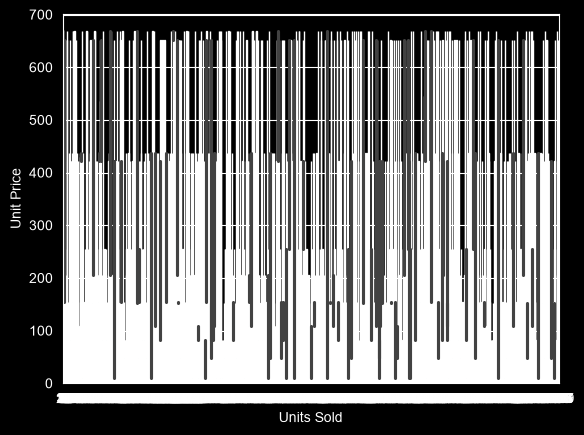

In [15]:
sns.barplot(data=data, x="Units Sold", y="Unit Price")

In [17]:
pivot=pd.crosstab(data["Country"],data["Item Type"])

In [18]:
pivot

Item Type,Baby Food,Beverages,Cereal,Clothes,Cosmetics,Fruits,Household,Meat,Office Supplies,Personal Care,Snacks,Vegetables
Country,,,,,,,,,,,,
Albania,1,3,0,3,4,0,3,2,2,0,1,2
Andorra,6,6,3,3,3,3,4,3,1,2,3,3
Armenia,2,1,3,2,0,3,3,5,1,3,4,2
Austria,0,3,3,1,1,3,2,1,5,3,2,4
Belarus,0,6,1,4,4,2,2,0,2,1,2,4
Belgium,0,3,2,1,4,5,1,2,2,0,3,3
Bosnia and Herzegovina,5,1,1,2,1,2,4,2,5,3,3,4
Bulgaria,2,2,1,3,2,3,3,4,4,1,3,2
Croatia,2,3,0,2,1,0,3,1,3,2,1,0


<Axes: xlabel='Item Type', ylabel='Country'>

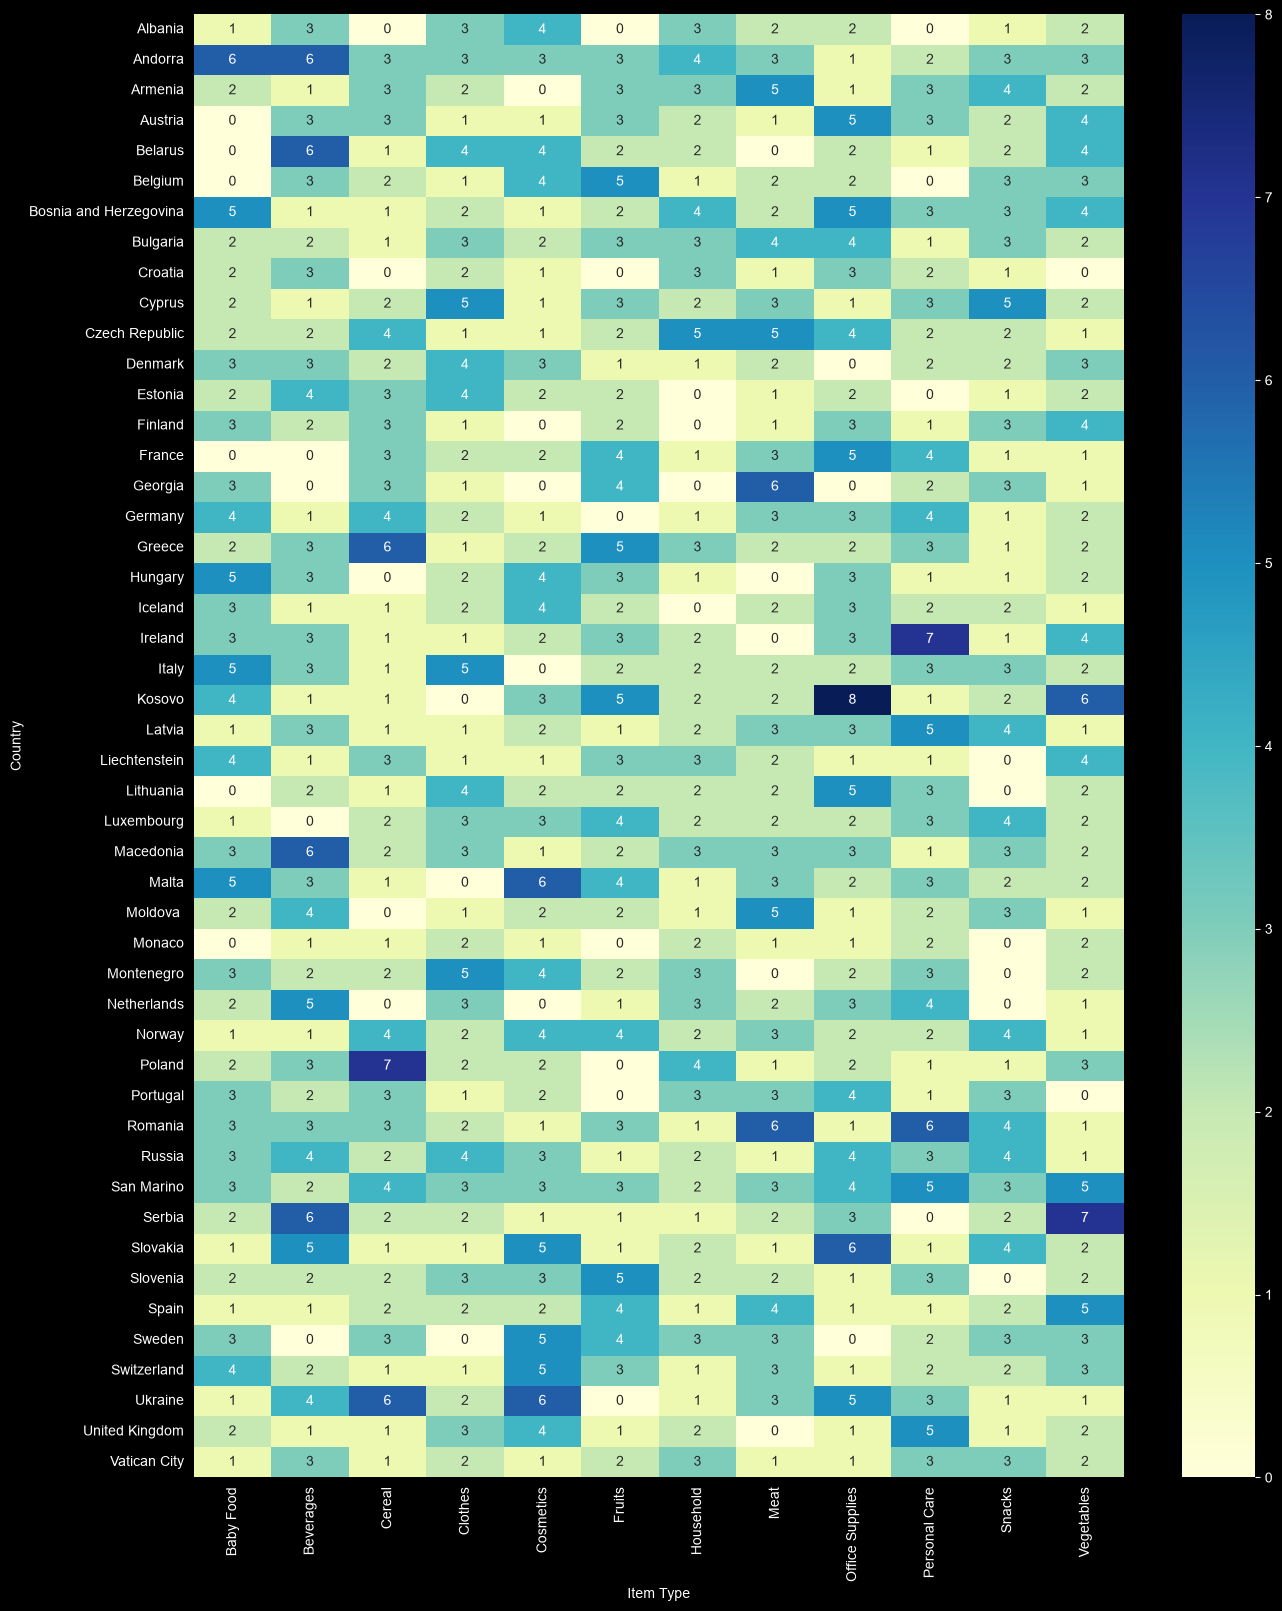

In [25]:
plt.figure(figsize=(15, 19))
sns.heatmap(pivot,annot=True,cmap="YlGnBu")

## Prediction Model


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [29]:
data

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price
0,Europe,Czech Republic,Beverages,Offline,C,2011-09-12,478051030,2011-09-29,4778,47.45
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,2013-10-14,919133651,2013-11-04,927,109.28
2,Europe,Austria,Cereal,Offline,C,2014-08-13,987410676,2014-09-06,5616,205.70
3,Europe,Bulgaria,Office Supplies,Online,L,2010-10-31,672330081,2010-11-29,6266,651.21
4,Europe,Estonia,Fruits,Online,L,2016-09-28,579463422,2016-11-01,4958,9.33
...,...,...,...,...,...,...,...,...,...,...
1325,Europe,Norway,Personal Care,Offline,M,2014-01-14,634033286,2014-01-15,3394,81.73
1326,Europe,Ukraine,Cereal,Offline,L,2014-04-14,559183347,2014-05-21,3633,205.70
1327,Europe,Armenia,Meat,Offline,M,2015-11-09,781416594,2015-12-23,7390,421.89
1328,Europe,Denmark,Clothes,Offline,H,2012-05-09,713357150,2012-06-03,7088,109.28


In [30]:
y = data["Units Sold"]

X = data[[
    "Unit Price",
    "Country",
    "Region",
    "Item Type"
]]

X = pd.get_dummies(X, drop_first=True)

In [33]:
y

0       4778
1        927
2       5616
3       6266
4       4958
        ... 
1325    3394
1326    3633
1327    7390
1328    7088
1329    9410
Name: Units Sold, Length: 1330, dtype: int64

In [35]:
X

,Unit Price,Country_Andorra,Country_Armenia,Country_Austria,Country_Belarus,Country_Belgium,Country_Bosnia and Herzegovina,Country_Bulgaria,Country_Croatia,Country_Cyprus,...,Item Type_Cereal,Item Type_Clothes,Item Type_Cosmetics,Item Type_Fruits,Item Type_Household,Item Type_Meat,Item Type_Office Supplies,Item Type_Personal Care,Item Type_Snacks,Item Type_Vegetables
0,47.45,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,109.28,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,205.70,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,651.21,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4,9.33,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1325,81.73,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1326,205.70,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1327,421.89,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1328,109.28,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [36]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [37]:
model=LinearRegression()

In [38]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](59,)","[ -0.5 , 93.36, 703.05,...,-469.86,-328.1 , -50.56]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](59,)","['Unit Price','Country_Andorra','Country_Armenia',..., 'Item Type_Personal Care','Item Type_Snacks','Item Type_Vegetables']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4792
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,59
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(58)


In [39]:
y_pred=model.predict(X_test)

In [40]:
# 8. Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 2425.91
RMSE: 2834.58
R²: -0.039


In [43]:
Results=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

In [44]:
Results

,Actual,Predicted
1172,7518,4337.998191
1141,1573,4417.488468
299,2396,4498.005452
752,611,4445.949837
1275,3086,6347.186280
...,...,...
729,1457,4874.098066
1245,4752,3303.217545
22,5242,5071.603135
305,634,4500.223293


In [46]:
Results["Error"] = Results["Actual"] - Results["Predicted"]

In [47]:
Results

,Actual,Predicted,Error
1172,7518,4337.998191,3180.001809
1141,1573,4417.488468,-2844.488468
299,2396,4498.005452,-2102.005452
752,611,4445.949837,-3834.949837
1275,3086,6347.186280,-3261.186280
...,...,...,...
729,1457,4874.098066,-3417.098066
1245,4752,3303.217545,1448.782455
22,5242,5071.603135,170.396865
305,634,4500.223293,-3866.223293


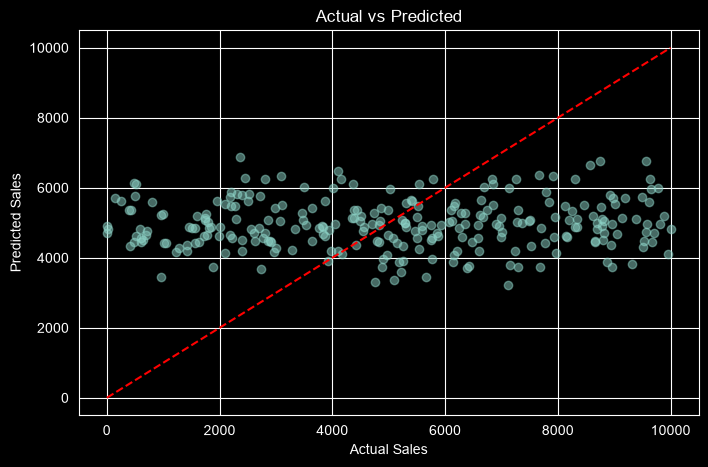

In [48]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

In [52]:
data.corr(numeric_only=True)["Units Sold"].sort_values(ascending=False).head(10)
data.corr(numeric_only=True)["Units Sold"].sort_values(ascending=False).tail(10)

Units Sold    1.000000
Order ID      0.032793
Unit Price   -0.047679
Name: Units Sold, dtype: float64

In [53]:
# 1. Check correlation with target first
print(data.corr(numeric_only=True)["Units Sold"].sort_values(ascending=False))

Units Sold    1.000000
Order ID      0.032793
Unit Price   -0.047679
Name: Units Sold, dtype: float64


In [62]:
# 2. Group rare countries
top_countries = data["Country"].value_counts().nlargest(8).index
data["Country_grouped"] = data["Country"].where(data["Country"].isin(top_countries), "Other")

# 3. Define target and features
y = data["Units Sold"]
X = data.drop(columns=["Units Sold", "Country"])

# 4. Encode EVERY remaining text column — not just one
X = pd.get_dummies(X, drop_first=True)

# 5. Confirm nothing text-based is left
print(X.dtypes.value_counts())
print(X.select_dtypes(include="object").columns.tolist())  # should print []

bool              23
datetime64[us]     2
int64              1
float64            1
Name: count, dtype: int64
[]


In [64]:
# 1. See every column and its type first
print(data.dtypes)

Region                        str
Country                       str
Item Type                     str
Sales Channel                 str
Order Priority                str
Order Date         datetime64[us]
Order ID                    int64
Ship Date          datetime64[us]
Units Sold                  int64
Unit Price                float64
Country_grouped               str
dtype: object


In [65]:
data["Order Date"] = pd.to_datetime(data["Order Date"])
data["Ship Date"] = pd.to_datetime(data["Ship Date"])

data["Order Month"] = data["Order Date"].dt.month
data["Shipping Days"] = (data["Ship Date"] - data["Order Date"]).dt.days


top_countries = data["Country"].value_counts().nlargest(8).index
data["Country_grouped"] = data["Country"].where(data["Country"].isin(top_countries), "Other")
y = data["Units Sold"]
X = data.drop(columns=[
    "Units Sold", "Country", "Order ID", "Order Date", "Ship Date"
               ])


X = pd.get_dummies(X, drop_first=True)


print(X.select_dtypes(include="object").columns.tolist())  # should be []


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

# 10. See which features matter
coeffs = pd.Series(model.coef_, index=X.columns).sort_values()


print(coeffs)

[]
MAE: 2702.528348477328
RMSE: 3140.0527914350973
R²: -0.07949808788754109
Item Type_Cereal                         -138.356274
Country_grouped_San Marino               -108.842238
Item Type_Cosmetics                      -108.138199
Country_grouped_Other                    -101.253202
Country_grouped_Bosnia and Herzegovina    -91.202713
Sales Channel_Online                      -78.189717
Item Type_Snacks                          -69.962960
Order Priority_L                          -62.982789
Country_grouped_Kosovo                    -53.440502
Item Type_Personal Care                   -49.533218
Unit Price                                -39.375998
Item Type_Household                       -26.847613
Country_grouped_Russia                    -25.538701
Country_grouped_Ukraine                    21.963688
Country_grouped_Romania                    33.954420
Item Type_Beverages                        42.688245
Item Type_Meat                             44.109277
Country_grouped_Malta  

In [66]:
print(X.assign(**{"Units Sold": y}).corr(numeric_only=True)["Units Sold"].sort_values(ascending=False))

Units Sold                                1.000000
Item Type_Clothes                         0.068893
Item Type_Fruits                          0.034854
Country_grouped_Malta                     0.025808
Order Priority_M                          0.024972
Item Type_Vegetables                      0.016973
Order Month                               0.015874
Shipping Days                             0.013319
Item Type_Beverages                       0.012870
Country_grouped_Russia                    0.012816
Item Type_Office Supplies                 0.007957
Country_grouped_Kosovo                    0.007071
Country_grouped_Ukraine                   0.002092
Order Priority_H                          0.000467
Country_grouped_Other                     0.000446
Country_grouped_Romania                  -0.002278
Item Type_Personal Care                  -0.007988
Country_grouped_San Marino               -0.008699
Sales Channel_Online                     -0.013003
Item Type_Meat                 

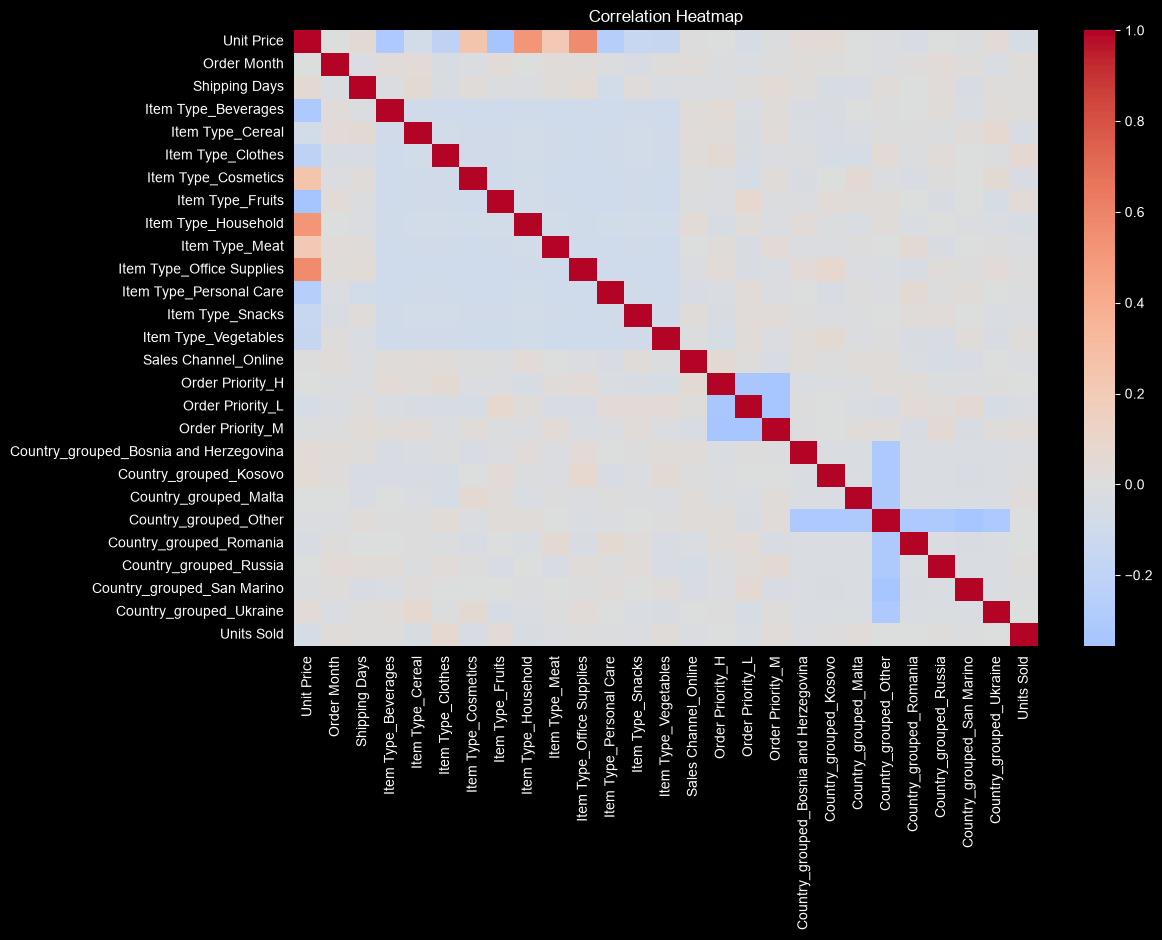

In [68]:
corr_data = X.copy()
corr_data["Units Sold"] = y

plt.figure(figsize=(12, 8))
sns.heatmap(corr_data.corr(numeric_only=True), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.show()

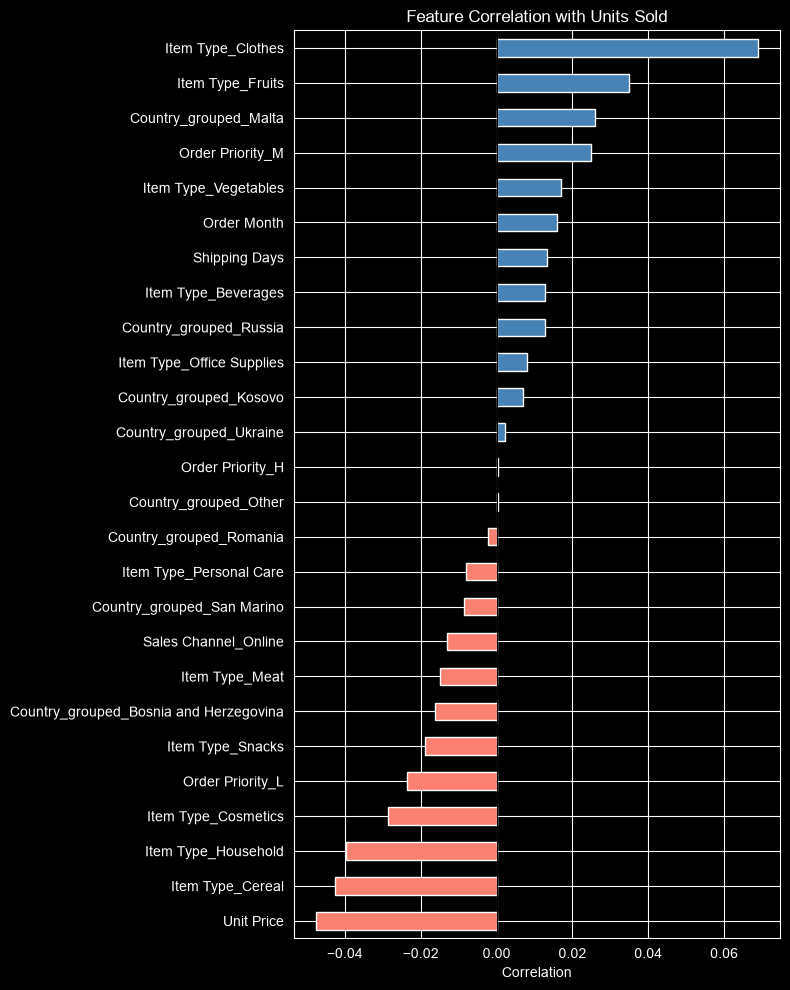

In [69]:
corr_with_target = corr_data.corr(numeric_only=True)["Units Sold"].drop("Units Sold").sort_values()

plt.figure(figsize=(8, 10))
corr_with_target.plot(kind="barh", color=(corr_with_target > 0).map({True: "steelblue", False: "salmon"}))
plt.title("Feature Correlation with Units Sold")
plt.xlabel("Correlation")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [70]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results["Error"] = results["Actual"] - results["Predicted"]

results

,Actual,Predicted,Error
893,4339,5170.284296,-831.284296
115,3600,4240.681722,-640.681722
526,3013,5180.240576,-2167.240576
175,7932,4825.209312,3106.790688
63,1138,4588.506148,-3450.506148
...,...,...,...
861,4080,4944.768022,-864.768022
554,339,4816.072917,-4477.072917
1022,8771,4789.822630,3981.177370
581,4934,4342.522959,591.477041


## Prediction Model
